# GAN Implementation with MNIST Dataset


This notebook demonstrates a simple implementation of a Generative Adversarial Network (GAN) using the MNIST dataset. The MNIST dataset is a collection of handwritten digits, and this notebook will train a GAN to generate new images similar to those in the MNIST dataset.


In [1]:
# -*- coding: utf-8 -*-
# PyTorch 实现的 MNIST Adversarial Autoencoder (AAE)

import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets
from torchvision import transforms
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt


In [9]:
# --------------------
# 超参数
# --------------------
img_rows, img_cols, channels = 28, 28, 1
img_shape = (channels, img_rows, img_cols)
latent_dim = 10
batch_size = 16
epsilon_std = 1.0
lr = 2e-4
b1, b2 = 0.5, 0.999
sample_interval = 200
epochs = 10000  # 与原脚本一致，每个“epoch”训练一个随机批次

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
np.random.seed(0)

In [10]:
# --------------------
# 数据（与 Keras 版一致：[-1,1] 归一化）
# --------------------
train_set = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=None  # 我们直接用原始张量，手动归一化，方便随机采样
)

# 归一化到 [-1, 1]，并加上通道维
X_train = train_set.data.float().unsqueeze(1) / 255.0   # [N,1,28,28], [0,1]
X_train = X_train * 2 - 1                               # [-1,1]
X_train = X_train.to(device)

In [ ]:
# --------------------
# 模型
# --------------------
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 512) # 输入展平 [N, 1, 28, 28] -> [N, 28*28]
        self.fc2 = nn.Linear(512, 512) # 隐藏层
        self.mu = nn.Linear(512, latent_dim) # 均值输出
        self.logvar = nn.Linear(512, latent_dim) # 对数方差输出
        self.act = nn.LeakyReLU(0.2, inplace=True) # 激活函数

    def reparameterize(self, mu, logvar): # 重参数化技巧
        eps = torch.randn(mu.size(0), mu.size(1), device=mu.device) * epsilon_std # 随机噪声
        # 这里的 eps 是标准正态分布的噪声
        # mu 和 logvar 是从编码器输出的均值和对数方差
        # 返回 z = mu + exp(0.5 * logvar) * eps
        # 这一步是重参数化技巧，确保梯度可以通过 mu 和 logvar 传播
        # 这样可以在训练时对潜在变量 z 进行采样
        # mu 是均值，logvar 是对数方差
        # eps 是从标准正态分布采样的噪声
        # 这里的 eps 是标准正态分布的噪声
        # mu 和 logvar 是从编码器输出的均值和对数方差   
        return mu + torch.exp(0.5 * logvar) * eps # 返回潜在变量 z

    def forward(self, x):
        x = x.view(x.size(0), -1) # 展平输入 [N, 1, 28, 28] -> [N, 28*28]
        h = self.act(self.fc1(x)) # 激活函数
        h = self.act(self.fc2(h)) # 隐藏层
        mu = self.mu(h) # 均值输出
        logvar = self.logvar(h) # 对数方差输出
        # 这里的 mu 和 logvar 是从编码器输出的均值和对数方差
        # mu 是潜在空间的均值，logvar 是潜在空间的对数方差
        # 这两个输出用于重参数化技巧
        # 重参数化技巧允许我们在训练过程中对潜在变量 z 进行采样
        # 通过 mu 和 logvar，我们可以生成潜在变量 z
        # 这一步是为了确保梯度可以通过 mu 和 logvar 传播
        # 这样可以在训练时对潜在变量 z 进行采样
        # 这里的 z 是从 mu 和 logvar 生成的潜在变量
        # 这一步是重参数化技巧，确保梯度可以通过 mu 和 logvar 传播
        # 这样可以在训练时对潜在变量 z 进行采样
        # 返回 z，训练时只用 z（与原 Keras 代码保持一致）
        z = self.reparameterize(mu, logvar) # 重参数化技巧
        # 这里的 z 是从 mu 和 logvar 生成的潜在变量
        # 这一步是重参数化技巧，确保梯度可以通过 mu 和 logvar 传播
        # 这样可以在训练时对潜在变量 z 进行采样
        # 返回 z，训练时只用 z（与原 Keras 代码保持一致）
        # 这里的 z 是从 mu 和 logvar 生成的潜在变量
        return z  # 训练里只用 z（与原 Keras 代码保持一致）


class Decoder(nn.Module):
    def __init__(self, latent_dim): # 初始化解码器 self: Decoder, latent_dim: 潜在空间维度
        super().__init__() # 初始化解码器
        self.fc1 = nn.Linear(latent_dim, 512) # 输入潜在变量 z
        self.fc2 = nn.Linear(512, 512) # 隐藏层
        self.fc3 = nn.Linear(512, 28*28) # 输出重构图像
        self.act = nn.LeakyReLU(0.2, inplace=True) # 激活函数

    def forward(self, z):
        h = self.act(self.fc1(z)) # 激活函数 
        h = self.act(self.fc2(h)) # 隐藏层
        x_hat = torch.tanh(self.fc3(h))  # 与 Keras: Dense(..., activation='tanh')
        x_hat = x_hat.view(z.size(0), 1, 28, 28) # 重构图像 [N, 28*28] -> [N, 1, 28, 28]
        # 这里的 x_hat 是解码器输出的重构图像
        # x_hat 是从潜在变量 z 重构的图像
        # 这一步是将潜在变量 z 解码为图像
        # x_hat.view(z.size(0), 1, 28, 28) 将输出形状调整为 [N, 1, 28, 28]
        return x_hat


class Discriminator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc1 = nn.Linear(latent_dim, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 1)
        self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, z):
        h = self.act(self.fc1(z))
        h = self.act(self.fc2(h))
        logit = self.fc3(h)  # 我们用 BCEWithLogitsLoss，所以这里不加 Sigmoid
        return logit

encoder = Encoder(latent_dim).to(device)
decoder = Decoder(latent_dim).to(device)
discriminator = Discriminator(latent_dim).to(device)


In [12]:
# --------------------
# 优化器 & 损失
# --------------------
mse_loss = nn.MSELoss()
bce_logits = nn.BCEWithLogitsLoss()

opt_D = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(b1, b2))
opt_G = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=lr, betas=(b1, b2))


In [13]:
# --------------------
# 采样与保存图片
# --------------------
os.makedirs("samples", exist_ok=True)

@torch.no_grad()
def sample_images(step, n_row=5, n_col=5):
    z = torch.randn(n_row * n_col, latent_dim, device=device)
    gen = decoder(z)
    # 反归一化到 [0,1]
    imgs = (gen + 1) / 2.0
    grid = make_grid(imgs, nrow=n_col, padding=2)
    save_image(grid, f"samples/mnist_{step}.png")

In [14]:
# --------------------
# 训练（按原 Keras 逻辑：每个“epoch”随机采样一个 batch）
# --------------------
def train(epochs, batch_size, sample_interval):
    N = X_train.size(0)
    valid = torch.ones(batch_size, 1, device=device)
    fake = torch.zeros(batch_size, 1, device=device)

    # 用于记录训练过程中D和G的loss，准确率和重建误差（mse）
    d_losses = []
    g_losses = []
    d_accs = []
    recon_losses = []

    for step in range(epochs):
        # ---- 取随机批次 ----
        idx = torch.randint(0, N, (batch_size,), device=device)
        imgs = X_train[idx]  # [B,1,28,28]

        # =========================
        # 1) 训练判别器 D
        # =========================
        discriminator.train()
        opt_D.zero_grad()

        z_fake = encoder(imgs).detach()
        z_real = torch.randn(batch_size, latent_dim, device=device)

        logit_real = discriminator(z_real)
        logit_fake = discriminator(z_fake)

        d_loss_real = bce_logits(logit_real, valid)
        d_loss_fake = bce_logits(logit_fake, fake)
        d_loss = 0.5 * (d_loss_real + d_loss_fake)
        d_loss.backward()
        opt_D.step()

        # 计算 D 的准确率（仅用于日志）
        with torch.no_grad():
            p_real = torch.sigmoid(logit_real)
            p_fake = torch.sigmoid(logit_fake)
            acc_real = (p_real > 0.5).float().mean()
            acc_fake = (p_fake < 0.5).float().mean()
            d_acc = 0.5 * (acc_real + acc_fake)

        # =========================
        # 2) 训练生成器（Encoder+Decoder）
        #    - 重建损失 MSE
        #    - 对抗损失：让 D(Encoder(x)) 判为 1
        # =========================
        # 冻结 D 的梯度，避免无谓反传到 D
        for p in discriminator.parameters():
            p.requires_grad = False

        opt_G.zero_grad()
        z = encoder(imgs)
        recon = decoder(z)

        recon_loss = mse_loss(recon, imgs)
        adv_logits = discriminator(z)
        adv_loss = bce_logits(adv_logits, valid)

        g_loss = 0.999 * recon_loss + 0.001 * adv_loss
        g_loss.backward()
        opt_G.step()

        for p in discriminator.parameters():
            p.requires_grad = True

        # 将当前的损失和准确率记录下来
        d_losses.append(d_loss.item())
        g_losses.append(g_loss.item())
        d_accs.append(d_acc.item())
        recon_losses.append(recon_loss.item())

        # 日志与采样
        if step % sample_interval == 0:
            print(f"{step} [D loss: {d_loss.item():.6f}, acc: {100*d_acc.item():.2f}%] "
                  f"[G loss: {g_loss.item():.6f}, mse: {recon_loss.item():.6f}]")
            sample_images(step)
    # 训练结束后绘制图像
    plt.figure(figsize=(12, 6))

    # 绘制 D 和 G 损失
    plt.subplot(1, 2, 1)
    plt.plot(d_losses, label="D loss")
    plt.plot(g_losses, label="G loss")
    plt.title("Discriminator and Generator Losses")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # 绘制 D 准确率 和 重建损失 (MSE)
    plt.subplot(1, 2, 2)
    plt.plot(d_accs, label="D Accuracy")
    plt.plot(recon_losses, label="Reconstruction Loss (MSE)")
    plt.title("Discriminator Accuracy and Reconstruction Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    plt.legend()

    # 显示图像
    plt.tight_layout()
    plt.show()


0 [D loss: 0.693635, acc: 43.75%] [G loss: 0.925844, mse: 0.926023]
200 [D loss: 0.059898, acc: 100.00%] [G loss: 0.130729, mse: 0.126531]
400 [D loss: 0.074984, acc: 96.88%] [G loss: 0.144102, mse: 0.139524]
600 [D loss: 0.067160, acc: 100.00%] [G loss: 0.120697, mse: 0.115941]
800 [D loss: 0.147993, acc: 90.62%] [G loss: 0.127016, mse: 0.123684]
1000 [D loss: 0.260458, acc: 90.62%] [G loss: 0.114171, mse: 0.111784]
1200 [D loss: 0.235461, acc: 93.75%] [G loss: 0.079211, mse: 0.077128]
1400 [D loss: 0.292992, acc: 84.38%] [G loss: 0.097904, mse: 0.095839]
1600 [D loss: 0.627079, acc: 62.50%] [G loss: 0.104514, mse: 0.103119]
1800 [D loss: 0.417980, acc: 87.50%] [G loss: 0.099874, mse: 0.098464]
2000 [D loss: 0.444387, acc: 87.50%] [G loss: 0.101906, mse: 0.100403]
2200 [D loss: 0.540668, acc: 68.75%] [G loss: 0.085193, mse: 0.084007]
2400 [D loss: 0.646313, acc: 65.62%] [G loss: 0.105010, mse: 0.104008]
2600 [D loss: 0.557515, acc: 71.88%] [G loss: 0.078732, mse: 0.077353]
2800 [D los

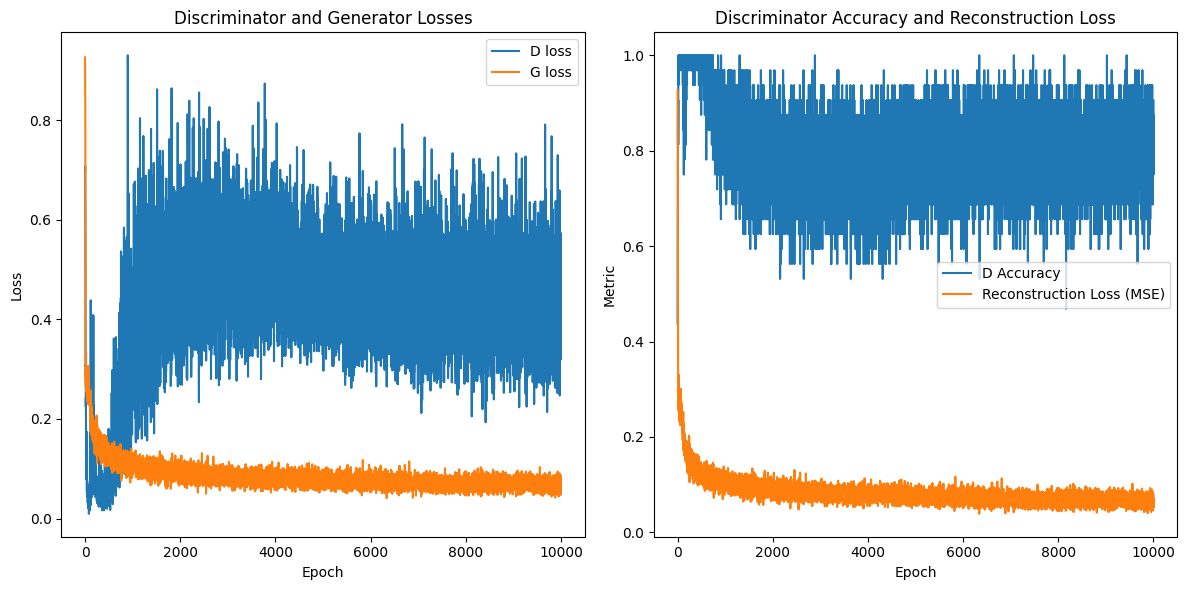

Saved samples to ./samples/


In [15]:
train(epochs=epochs, batch_size=batch_size, sample_interval=sample_interval)

# 生成一张单图示例
with torch.no_grad():
    z = torch.randn(1, latent_dim, device=device)
    gen = decoder(z)
    img = (gen + 1) / 2.0
    save_image(img, "samples/single.png")
    print("Saved samples to ./samples/")
